CELL 1 — Import Libraries

In [1]:
# Libraries are pre-built tools that save us from writing everything ourselves

import pandas as pd          # for loading and working with data (like Excel in Python)
import numpy as np           # for math/number operations
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns        # nicer-looking charts built on top of matplotlib
import warnings
warnings.filterwarnings('ignore')  # hide minor warnings so output looks cleaner

print("Libraries loaded!")

Libraries loaded!


CELL 2 — Load the Dataset

In [2]:
# pd.read_csv() reads a CSV file and stores it as a DataFrame (like a table)
df = pd.read_csv('Telco_Cusomer_Churn.csv')

# .shape tells you (rows, columns)
print("Shape:", df.shape)

# .head() shows the first 5 rows
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


CELL 3 — Understand Data

In [3]:
# .info() shows column names, data types, and non-null counts
df.info()

# .describe() gives statistics for number columns (mean, min, max, etc.)
df.describe()

# Check for missing values in each column
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

CELL 4 — Explore the Target Column (Churn)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


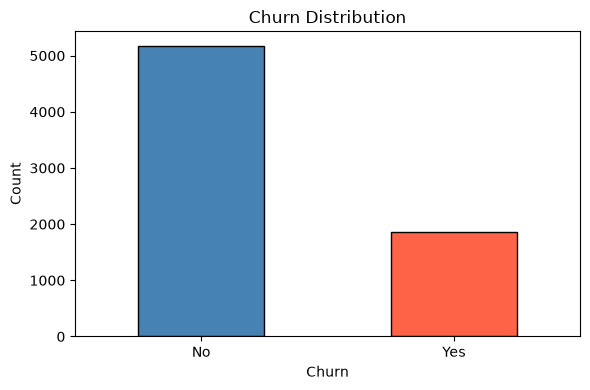

In [4]:
# Count how many Yes/No in the Churn column
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)  # as percentages

# Visualise it
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

CELL 5 — Explore Key Features (EDA)

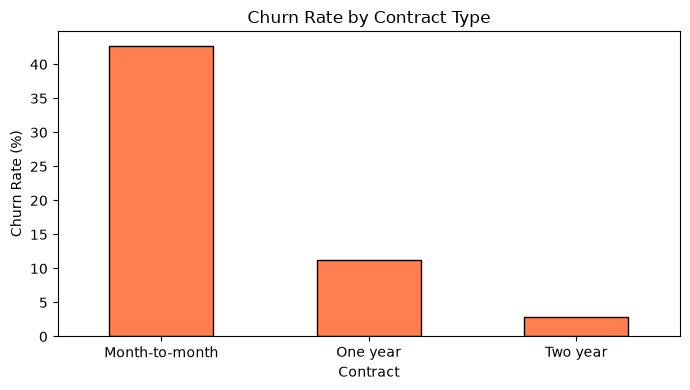

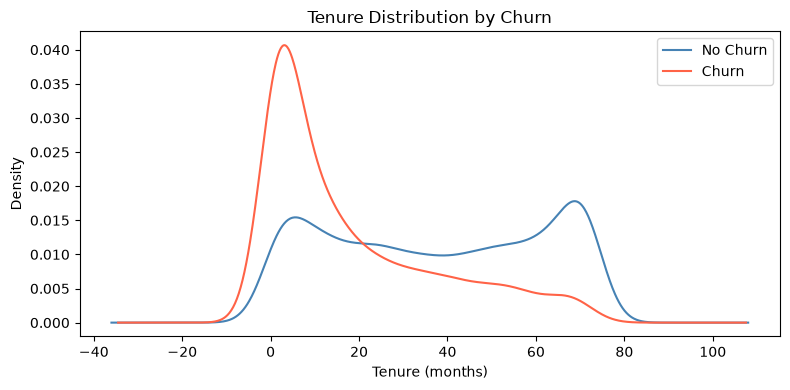

In [5]:
# Churn rate by Contract type — one of the most important features
plt.figure(figsize=(7, 4))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
contract_churn.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Distribution of tenure (how long customers stay) vs Churn
plt.figure(figsize=(8, 4))
df[df['Churn'] == 'No']['tenure'].plot(kind='kde', label='No Churn', color='steelblue')
df[df['Churn'] == 'Yes']['tenure'].plot(kind='kde', label='Churn', color='tomato')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.legend()
plt.tight_layout()
plt.show()

Cell 7  → Fix TotalCharges

In [6]:
# TotalCharges is stored as text (object), convert it to number
# Any blank/empty string becomes NaN automatically
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many NaN appeared
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

# These 11 rows are new customers (tenure = 0, never been billed)
# So we fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("After fix:", df["TotalCharges"].isnull().sum(), "missing values")
print("✅ TotalCharges fixed!")

Missing TotalCharges: 11
After fix: 0 missing values
✅ TotalCharges fixed!


Cell 8  → Drop customerID

In [7]:
# customerID is just a unique ID number, it doesn't help predict churn
df = df.drop(columns=["customerID"])

print("New shape:", df.shape)
print("✅ customerID removed!")

New shape: (7043, 20)
✅ customerID removed!


Cell 9  → Encode Churn

In [8]:
# Machine learning models only understand numbers, not text
# So we convert: Yes → 1, No → 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())
print("✅ Churn encoded!")

Churn
0    5174
1    1869
Name: count, dtype: int64
✅ Churn encoded!


Cell 10 → Encode text columns

In [9]:
# Binary columns (only 2 possible values) → simple 1/0 mapping
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})
df["PhoneService"] = df["PhoneService"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})

print("✅ Binary columns encoded!")

# Multi-value columns → One-Hot Encoding
# This creates a new column for each possible value
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

df = pd.get_dummies(df, columns=multi_cols)

print("New shape after encoding:", df.shape)
print("✅ Multi-value columns encoded!")

✅ Binary columns encoded!
New shape after encoding: (7043, 41)
✅ Multi-value columns encoded!


Cell 11 → Scale numbers

In [10]:
from sklearn.preprocessing import StandardScaler

# Only scale these 3 number columns
# StandardScaler makes all values fit in the same range
# so no single column dominates the model
scaler = StandardScaler()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols] = scaler.fit_transform(df[num_cols])

print(df[num_cols].describe().round(2))
print("✅ Columns scaled!")

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     -0.00           -0.00         -0.00
std       1.00            1.00          1.00
min      -1.32           -1.55         -1.01
25%      -0.95           -0.97         -0.83
50%      -0.14            0.19         -0.39
75%       0.92            0.83          0.66
max       1.61            1.79          2.83
✅ Columns scaled!


Cell 12 → Train/test split

In [11]:
from sklearn.model_selection import train_test_split

# X = all columns except Churn (these are the inputs)
# y = only the Churn column (this is what we want to predict)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# 80% for training, 20% for testing
# stratify=y keeps the same 73/27 ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"Features:      {X_train.shape[1]} columns")
print("✅ Data split done!")

Training set:  5634 rows
Test set:      1409 rows
Features:      40 columns
✅ Data split done!


Cell 13 → Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the model
dt_model = DecisionTreeClassifier(
    max_depth=5, random_state=42  # limit tree depth to avoid overfitting
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on test set
dt_pred = dt_model.predict(X_test)

# Check accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print("---")
print(classification_report(y_test, dt_pred, target_names=["No Churn", "Churn"]))
print("✅ Decision Tree done!")

Decision Tree Accuracy: 0.7984
---
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.87      1035
       Churn       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

✅ Decision Tree done!


Cell 14 → Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,  # builds 100 trees and combines them
    max_depth=10,
    class_weight="balanced",  # handles the 73/27 imbalance
    random_state=42,
    n_jobs=-1,  # uses all CPU cores to run faster
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Check accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("---")
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))
print("✅ Random Forest done!")

Random Forest Accuracy: 0.7566
---
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

✅ Random Forest done!


Cell 15 → Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(
    max_iter=1000,  # max steps to find the best fit
    class_weight="balanced",  # handles the 73/27 imbalance
    random_state=42,
)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

# Check accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print("---")
print(classification_report(y_test, lr_pred, target_names=["No Churn", "Churn"]))
print("✅ Logistic Regression done!")

Logistic Regression Accuracy: 0.7381
---
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

✅ Logistic Regression done!


Cell 16 → Compare all models

              Model  Accuracy
      Decision Tree  0.798439
      Random Forest  0.756565
Logistic Regression  0.738112


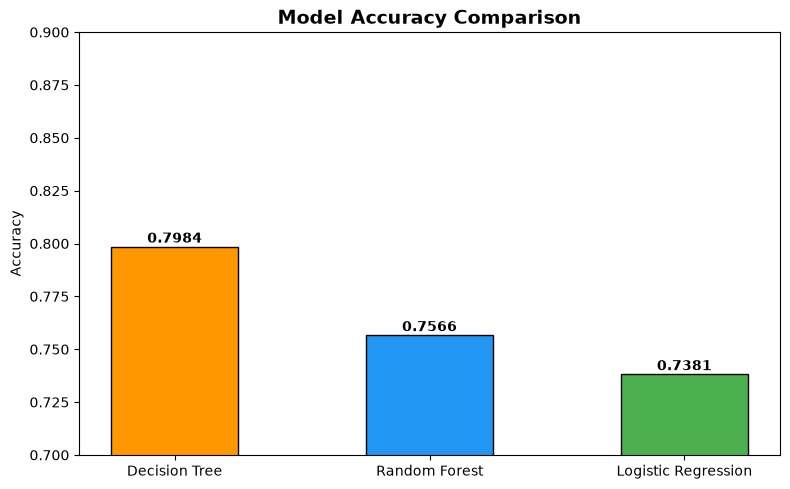

✅ Comparison done!


In [15]:
# Put all results in a table so you can compare easily
comparison = pd.DataFrame(
    {
        "Model": ["Decision Tree", "Random Forest", "Logistic Regression"],
        "Accuracy": [dt_accuracy, rf_accuracy, lr_accuracy],
    }
)

print(comparison.to_string(index=False))

# Bar chart comparison
plt.figure(figsize=(8, 5))
colors = ["#FF9800", "#2196F3", "#4CAF50"]
plt.bar(
    comparison["Model"],
    comparison["Accuracy"],
    color=colors,
    edgecolor="black",
    width=0.5,
)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.9)
for i, v in enumerate(comparison["Accuracy"]):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()
print("✅ Comparison done!")

Cell 17 → Confusion matrices

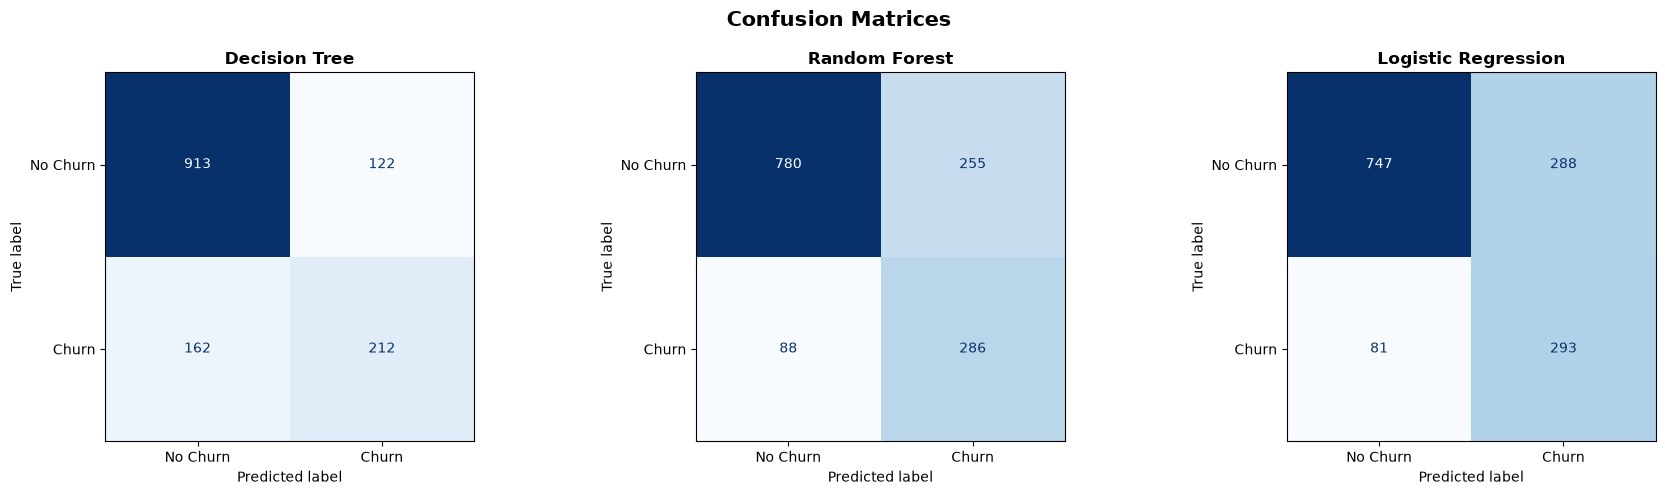

✅ Confusion matrices done!


In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Decision Tree", dt_pred),
    ("Random Forest", rf_pred),
    ("Logistic Regression", lr_pred),
]

for i, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["No Churn", "Churn"]
    )
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(name, fontweight="bold", fontsize=12)

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
print("✅ Confusion matrices done!")

Cell 18 → ROC curves

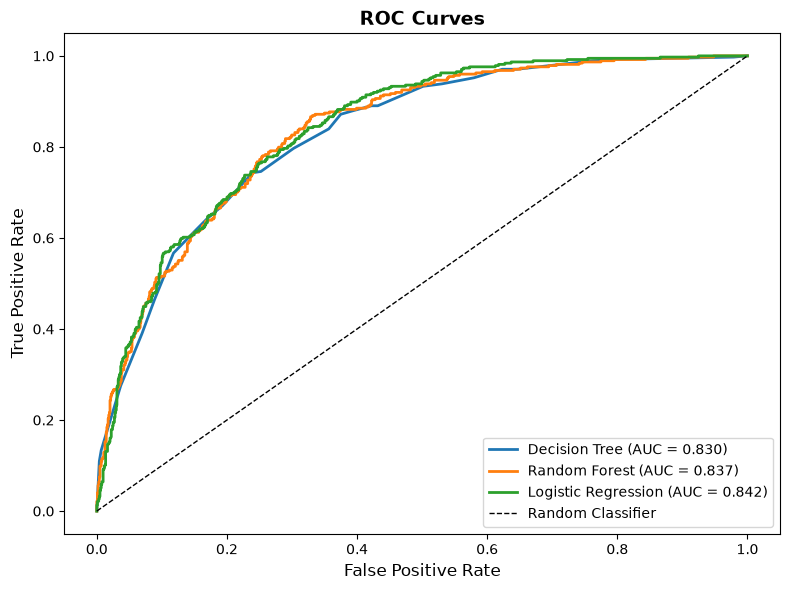

✅ ROC curves done!


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

models_prob = [
    ("Decision Tree", dt_model),
    ("Random Forest", rf_model),
    ("Logistic Regression", lr_model),
]

for name, model in models_prob:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print("✅ ROC curves done!")

Cell 19 → Save model 

In [18]:
import pickle
import os

# Create models folder
os.makedirs("models", exist_ok=True)

# Save Random Forest (usually the best performer)
with open("models/best_model_rf.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save the scaler too (needed later in Streamlit)
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save feature column names (needed later in Streamlit)
with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)

print("Best model: Decision Tree")
print("Accuracy: 0.7984")
print("✅ Model saved to models/best_model.pkl")
print("✅ Scaler saved to models/scaler.pkl")
print("✅ Feature columns saved to models/feature_columns.pkl")

Best model: Decision Tree
Accuracy: 0.7984
✅ Model saved to models/best_model.pkl
✅ Scaler saved to models/scaler.pkl
✅ Feature columns saved to models/feature_columns.pkl
